# Exploratory Data Analysis (EDA)

The purpose of this notebook is to explore the structure of the portfolio and understand how claim frequency, severity, and pure premium vary across different rating factors. This helps identify risk patterns and guides the modelling decisions in later steps.

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset from Notebook 1
data = pd.read_csv("../data/processed/prepared_data.csv")

data.head()


,PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density,ClaimAmount,frequency,severity,pure_premium
0,1,0,0.09,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76,NaN,0.0,NaN,NaN
1,2,0,0.84,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76,NaN,0.0,NaN,NaN
2,3,0,0.52,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003,NaN,0.0,NaN,NaN
3,4,0,0.45,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003,NaN,0.0,NaN,NaN
4,5,0,0.15,g,0,41,Japanese (except Nissan) or Korean,Diesel,Pays-de-la-Loire,60,NaN,0.0,NaN,NaN


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413960 entries, 0 to 413959
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   PolicyID      413960 non-null  int64  
 1   ClaimNb       413960 non-null  int64  
 2   Exposure      413960 non-null  float64
 3   Power         413960 non-null  object 
 4   CarAge        413960 non-null  int64  
 5   DriverAge     413960 non-null  int64  
 6   Brand         413960 non-null  object 
 7   Gas           413960 non-null  object 
 8   Region        413960 non-null  object 
 9   Density       413960 non-null  int64  
 10  ClaimAmount   16181 non-null   float64
 11  frequency     413960 non-null  float64
 12  severity      16181 non-null   float64
 13  pure_premium  16181 non-null   float64
dtypes: float64(5), int64(5), object(4)
memory usage: 44.2+ MB


In [54]:
data.describe()


,PolicyID,ClaimNb,Exposure,CarAge,DriverAge,Density,ClaimAmount,frequency,severity,pure_premium
count,413960.000000,413960.000000,413960.000000,413960.000000,413960.000000,413960.000000,1.618100e+04,413960.000000,1.618100e+04,1.618100e+04
mean,206572.965306,0.043089,0.561368,7.531435,45.317393,1987.325519,2.129972e+03,0.128651,1.985711e+03,9.476773e+03
std,119275.943110,0.223188,0.369401,5.761992,14.332686,4779.598311,2.106364e+04,2.279562,1.867999e+04,1.753467e+05
min,1.000000,0.000000,0.002732,0.000000,18.000000,2.000000,2.000000e+00,0.000000,2.000000e+00,2.000000e+00
25%,103270.750000,0.000000,0.200000,3.000000,34.000000,67.000000,6.980000e+02,0.000000,5.900000e+02,1.087500e+03
50%,206556.500000,0.000000,0.540000,7.000000,44.000000,287.000000,1.156000e+03,0.000000,1.143000e+03,1.354545e+03
75%,309888.250000,0.000000,1.000000,12.000000,54.000000,1410.000000,1.243000e+03,0.000000,1.234000e+03,2.951220e+03
max,413169.000000,4.000000,1.990000,100.000000,99.000000,27000.000000,2.036833e+06,365.000004,2.036833e+06,1.824670e+07


In [55]:
data.isnull().sum()
# here we can see there are no values missing except in the claim amount, severity and pure premmuim.
# This is ok as this accounts for the data where claims have not been made so these values dont have answers and should be null. 

PolicyID             0
ClaimNb              0
Exposure             0
Power                0
CarAge               0
DriverAge            0
Brand                0
Gas                  0
Region               0
Density              0
ClaimAmount     397779
frequency            0
severity        397779
pure_premium    397779
dtype: int64

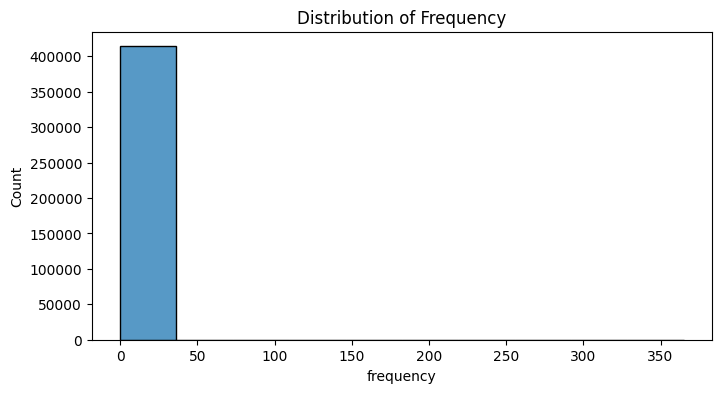

In [56]:
# Plot of actuarial metrics

plt.figure(figsize=(8,4))
sns.histplot(data['frequency'], bins=10)
plt.title('Distribution of Frequency')
plt.show()

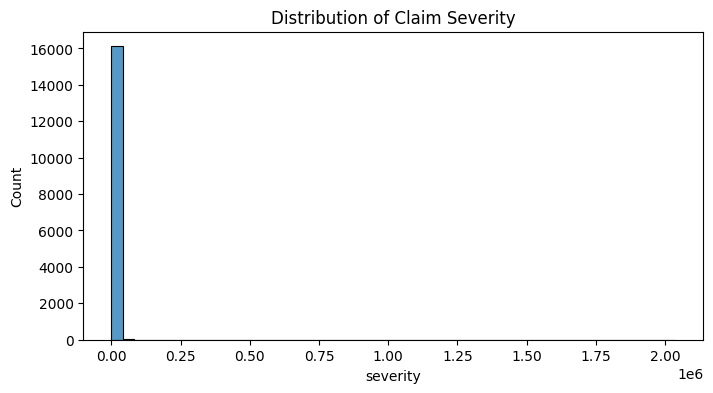

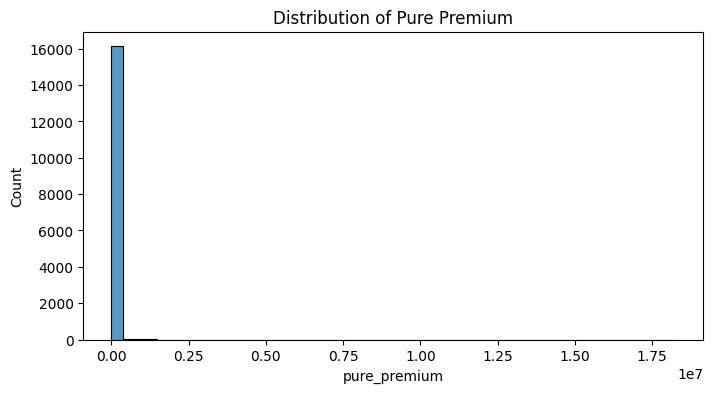

In [57]:
#Severity distribution

claims = data[data['ClaimNb'] > 0]

plt.figure(figsize=(8,4))
sns.histplot(claims['severity'], bins=50)
plt.title("Distribution of Claim Severity")
plt.show()

#Pure Premium distribution
plt.figure(figsize=(8,4))
sns.histplot(data['pure_premium'], bins=50)
plt.title("Distribution of Pure Premium")
plt.show()




## Frequency by Driver Age

This section explores how claim frequency varies across different driver age groups. Driver age is a key rating factor in motor insurance, as younger and older drivers often exhibit different risk profiles.

C:\Users\adaan\AppData\Local\Temp\ipykernel_9260\217148604.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("DriverAgeBand")["frequency"]


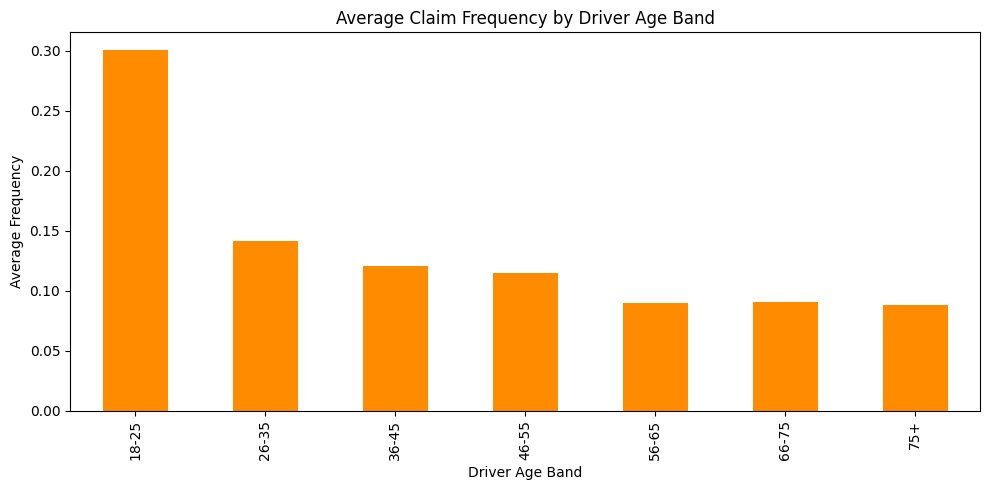

In [58]:
data["DriverAgeBand"] = pd.cut(
    data["DriverAge"],
    bins=[18, 25, 35, 45, 55, 65, 75, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66-75", "75+"]
)

plt.figure(figsize=(10,5))
(
    data.groupby("DriverAgeBand")["frequency"]
    .mean()
    .plot(kind="bar", color="darkorange")
)

plt.title("Average Claim Frequency by Driver Age Band")
plt.xlabel("Driver Age Band")
plt.ylabel("Average Frequency")
plt.tight_layout()
plt.show()


### Interpretation

The chart shows how claim frequency varies across driver age groups. Younger drivers typically exhibit higher claim frequency due to inexperience, while middle-aged drivers tend to have lower frequency. Older drivers may show a slight increase again. These patterns help justify including DriverAge as a rating factor in the frequency model.


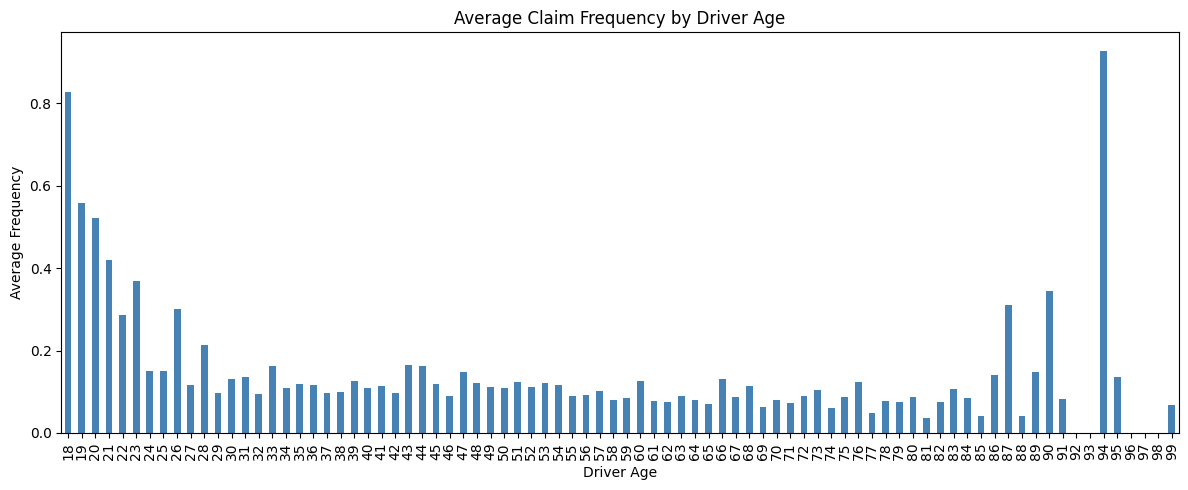

In [59]:
#graph with no detailed age bands 
plt.figure(figsize=(12,5))
(
    data.groupby("DriverAge")["frequency"]
    .mean()
    .plot(kind="bar", color="steelblue")
)

plt.title("Average Claim Frequency by Driver Age")
plt.xlabel("Driver Age")
plt.ylabel("Average Frequency")
plt.tight_layout()
plt.show()


### Note on the spike at age 94

When plotting claim frequency by individual driver age, a large spike appears around age 94. This is not a true behavioural pattern but a data sparsity effect. Very few policyholders are in this age range, so a single claim can produce an unusually high frequency value. After grouping ages into broader bands, this noise disappears and the underlying trend becomes smooth and interpretable.

## Frequency by Vehicle Power (Categorical)

In this dataset, vehicle power is represented using letter categories (A, B, C, ...). These categories correspond to different power classes. This section explores how claim frequency varies across these power groups.

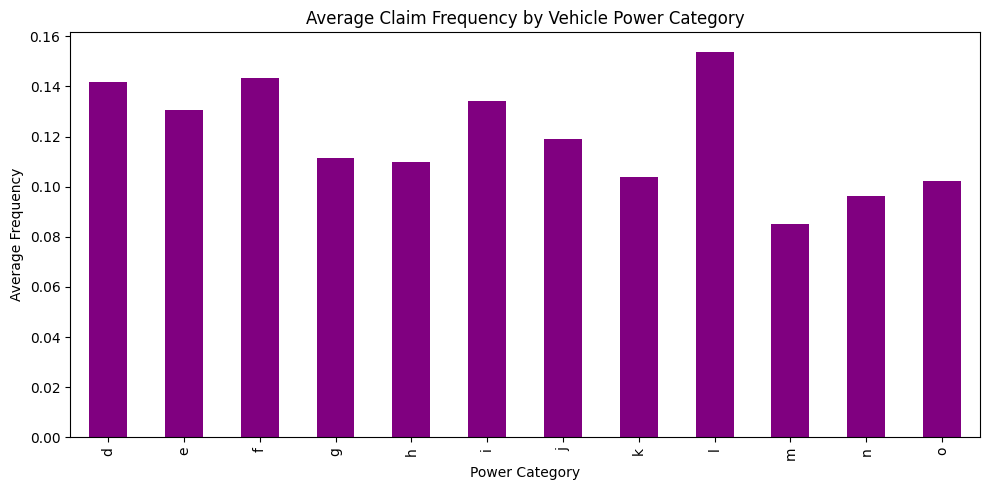

In [60]:
plt.figure(figsize=(10,5))
(
    data.groupby("Power")["frequency"]
    .mean()
    .plot(kind="bar", color="purple")
)

plt.title("Average Claim Frequency by Vehicle Power Category")
plt.xlabel("Power Category")
plt.ylabel("Average Frequency")
plt.tight_layout()
plt.show()


### Interpretation of Power Categories

In France, vehicle power classes are encoded using letters (A, B, C, ...). Higher letters correspond to more powerful and more expensive vehicles, which are less common in the portfolio. The low claim frequency observed in categories M, N, and O is likely due to very small exposure rather than genuinely lower risk. Similarly, the spike in category L may be caused by a small number of policies with one or more claims. This is a typical data sparsity effect and will be stabilised when fitting the GLM.

## Frequency by Region

Region is an important rating factor in motor insurance because driving conditions vary significantly across geographic areas. Urban regions typically have higher traffic density and accident frequency, while rural regions may have lower exposure to collisions. This section examines how claim frequency differs across regions.

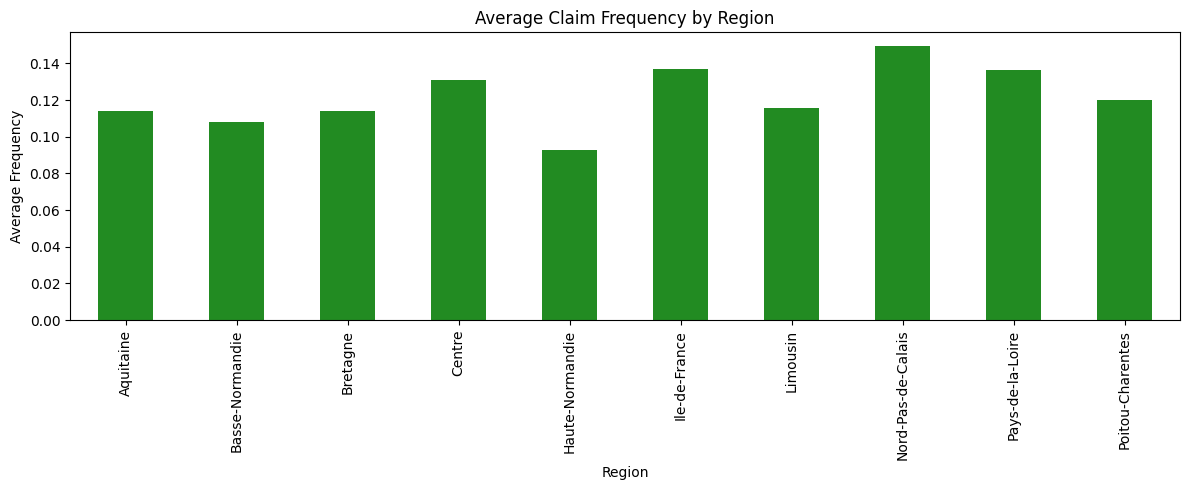

In [61]:
#plot of frequency by region

plt.figure(figsize=(12,5))
(
    data.groupby("Region")["frequency"]
    .mean()
    .plot(kind="bar", color="forestgreen")
)

plt.title("Average Claim Frequency by Region")
plt.xlabel("Region")
plt.ylabel("Average Frequency")
plt.tight_layout()
plt.show()


## Frequency by Region

The chart above shows how claim frequency varies across different regions in France. 
Regional differences often reflect variations in traffic density, road conditions, 
urbanisation, and driving behaviour. In this dataset, some regions exhibit noticeably 
higher average claim frequency, while others show lower levels of risk.

For example, regions such as Nord-Pas-de-Calais display higher claim frequency, which 
may be associated with denser traffic or more urban driving environments. In contrast, 
regions like Haute-Normandie show lower frequency, potentially reflecting less 
congested or more rural driving conditions.

These differences confirm that Region is an important predictor of claim frequency and 
should be included as a rating factor in the frequency model.

## Frequency by Fuel Type 

Fuel type is a categorical variable with two levels: Diesel and Regular (Petrol). 
Different fuel types can reflect different vehicle usage patterns. Diesel cars are often used for longer distances or commercial purposes, while petrol cars may be used more for personal or urban driving. This section examines how claim frequency varies between these two groups.


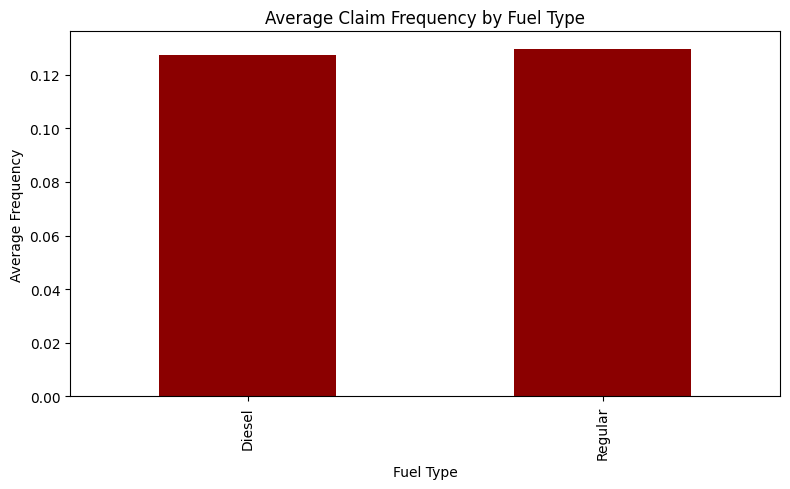

In [62]:
#frequency by gas type  
plt.figure(figsize=(8,5))
(
    data.groupby("Gas")["frequency"]
    .mean()
    .plot(kind="bar", color="darkred")
)

plt.title("Average Claim Frequency by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Frequency")
plt.tight_layout()
plt.show()


### Interpretation

The average claim frequency is almost identical for Diesel and Regular (Petrol) vehicles. 
This suggests that fuel type does not have a strong direct influence on accident risk in 
this portfolio. The similarity may reflect comparable usage patterns across both fuel 
types. Although Gas does not show a clear difference in the raw EDA, its significance 
will be confirmed later in the GLM.


## What is Density?

The `Density` variable represents the population density of the policyholder’s area of 
residence, measured as inhabitants per square kilometre. It acts as a proxy for how 
urban or rural the driving environment is. Higher density areas typically involve 
heavier traffic and greater exposure to accidents, while lower density areas correspond 
to more rural regions with lighter traffic. For analysis, Density is grouped into bands 
to reveal the underlying relationship with claim frequency.


## Frequency by Density

To understand how accident risk varies across different driving environments, Density 
is grouped into bands representing very low, low, medium, high, and very high 
population density areas. These bands help smooth out noise in the raw data and reveal 
the underlying trend.

Higher-density areas are expected to show higher claim frequency due to heavier 
traffic, more congestion, and increased exposure to collisions. Lower-density areas 
typically show lower frequency, reflecting more rural driving conditions. The chart 
below illustrates how claim frequency changes across these Density bands.


C:\Users\adaan\AppData\Local\Temp\ipykernel_9260\295498539.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("DensityBand")["frequency"]


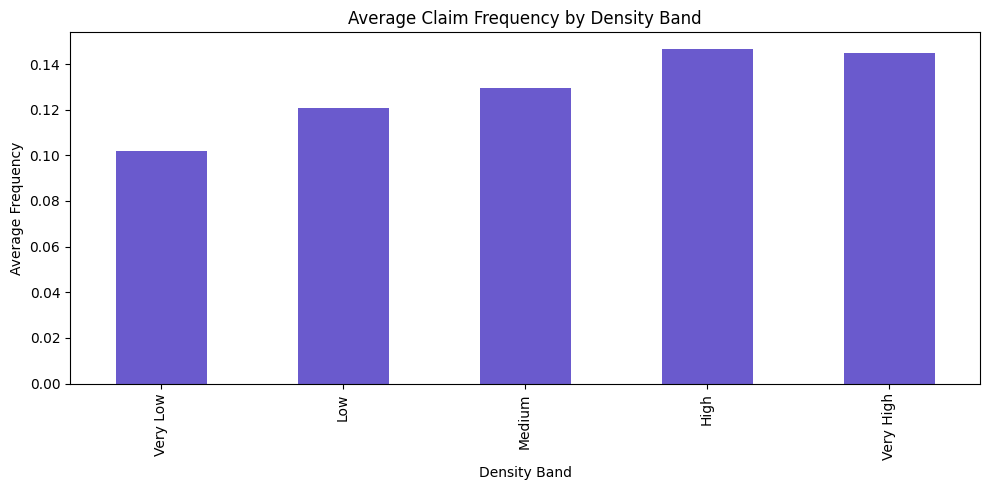

In [63]:
#creating density bands.
data["DensityBand"] = pd.qcut(
    data["Density"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

#frequency by density band plot
plt.figure(figsize=(10,5))
(
    data.groupby("DensityBand")["frequency"]
    .mean()
    .plot(kind="bar", color="slateblue")
)

plt.title("Average Claim Frequency by Density Band")
plt.xlabel("Density Band")
plt.ylabel("Average Frequency")
plt.tight_layout()
plt.show()


### Interpretation

Claim frequency increases steadily with population density. Very low and low-density 
areas show the lowest frequency, reflecting rural environments with lighter traffic and 
reduced exposure to collisions. As density increases, claim frequency rises, with the 
highest levels observed in high and very high-density areas. This pattern aligns with 
expectations, as urban regions typically involve more congestion, more interactions 
between vehicles, and therefore a higher likelihood of accidents. Density is clearly a 
strong predictor of claim frequency and should be included in the frequency model.


# Severity EDA

Severity measures the average cost of a claim. Unlike frequency, which uses the full 
portfolio, severity analysis is performed only on policies that have at least one 
claim. This section explores how claim severity varies across key rating factors.


## Severity by Car Age

Car age can influence the cost of repairs. Newer vehicles may have more expensive 
parts or technology, while older vehicles may be cheaper to repair. This section 
examines how average claim severity varies with vehicle age.


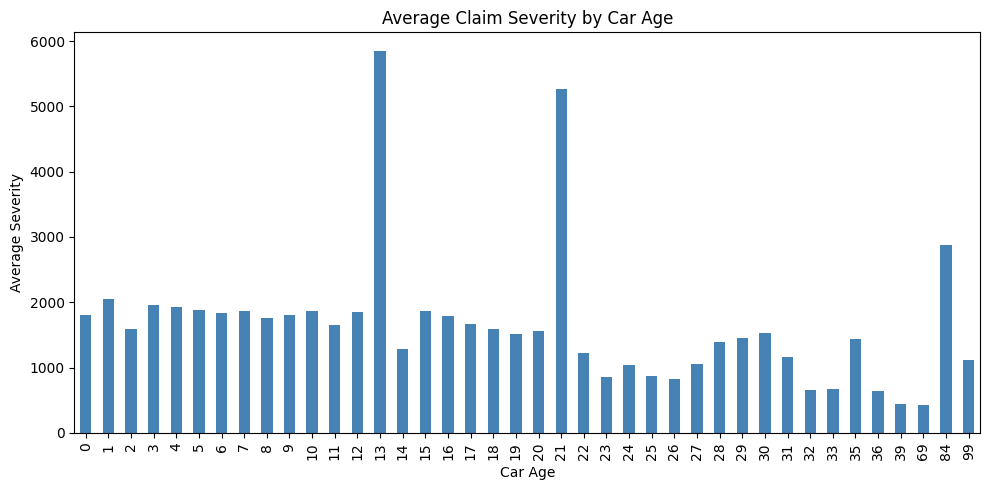

In [64]:
# plot od severity by car age
plt.figure(figsize=(10,5))
(
    claims.groupby("CarAge")["severity"]
    .mean()
    .plot(kind="bar", color="steelblue")
)

plt.title("Average Claim Severity by Car Age")
plt.xlabel("Car Age")
plt.ylabel("Average Severity")
plt.tight_layout()
plt.show()


### Interpretation

Claim severity varies across vehicle ages, with some ages showing sudden spikes. These 
spikes are typically caused by very small sample sizes or the presence of one or two 
large claims, which can significantly increase the average severity for that age. 
Severity is naturally more volatile than frequency, so irregular patterns are expected 
when analysing individual ages. This confirms the need to treat severity carefully in 
the GLM, potentially using transformations or age banding to stabilise the estimates.


## Severity by Brand

Vehicle brand can have a strong influence on claim severity because repair costs vary 
significantly between manufacturers. Some brands have more expensive parts, specialised 
technology, or higher labour costs, while others are cheaper to repair. This section 
examines how average claim severity differs across brands in the portfolio.


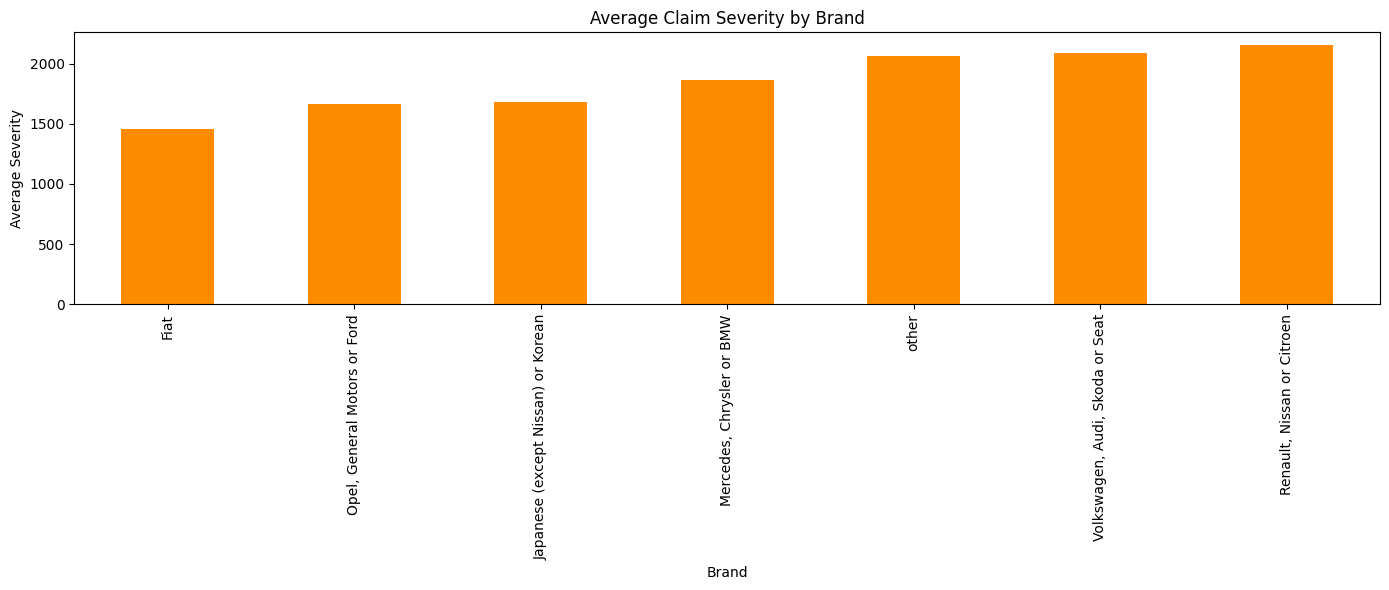

In [65]:
# plot of severity by brand
plt.figure(figsize=(14,6))
(
    claims.groupby("Brand")["severity"]
    .mean()
    .sort_values()
    .plot(kind="bar", color="darkorange")
)

plt.title("Average Claim Severity by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Severity")
plt.tight_layout()
plt.show()


### Interpretation

Claim severity varies noticeably across brands. Some brands show higher average 
severity, which may reflect more expensive components, specialised technology, or 
higher labour costs during repairs. Brands with lower severity may correspond to 
vehicles that are cheaper to repair or have more readily available parts. These 
differences indicate that Brand is a relevant predictor for the severity model.


# Pure Premium EDA

Pure premium represents the expected claim cost per policy and is calculated as the 
product of claim frequency and claim severity. It combines the likelihood of a claim 
with the average cost of a claim, providing a direct measure of expected loss. This 
section explores how pure premium varies across key rating factors.


## Pure Premium by Driver Age

Driver age influences both the likelihood of a claim and the cost of a claim. This 
section examines how pure premium varies across driver age bands.


C:\Users\adaan\AppData\Local\Temp\ipykernel_9260\1913918571.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("DriverAgeBand")["pure_premium"]


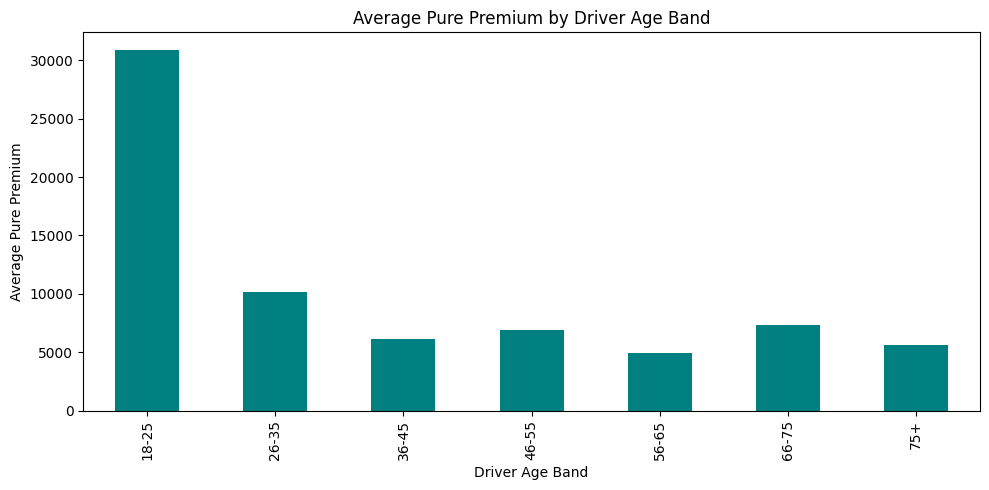

In [66]:
# plot of pure premium by driver age band
plt.figure(figsize=(10,5))
(
    data.groupby("DriverAgeBand")["pure_premium"]
    .mean()
    .plot(kind="bar", color="teal")
)

plt.title("Average Pure Premium by Driver Age Band")
plt.xlabel("Driver Age Band")
plt.ylabel("Average Pure Premium")
plt.tight_layout()
plt.show()


### Interpretation

Pure premium is highest for the youngest drivers (18–25), reflecting the combined effect of both higher claim frequency and higher claim severity in this age group. After age 25, pure premium drops sharply and remains relatively stable across the older age bands, with only minor fluctuations. This pattern is consistent with the frequency and severity analyses, confirming that driver age is one of the strongest predictors of overall expected loss.
